In [1]:
!pip install seaborn

In [4]:
import ipywidgets as widgets
from IPython.display import display

upload = widgets.FileUpload(accept='.csv', multiple=False)
display(upload)

FileUpload(value={}, accept='.csv', description='Upload')

FileUpload(value={}, accept='.csv', description='Upload')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

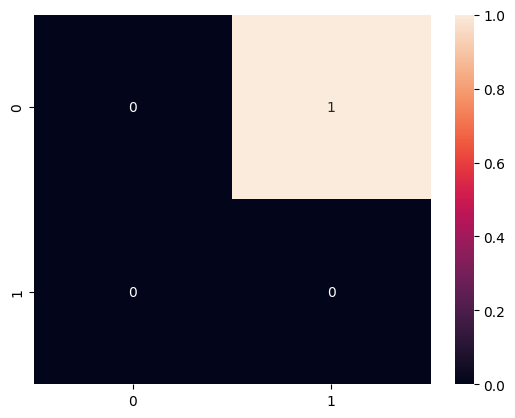

In [5]:
import torch
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display
import io

upload = widgets.FileUpload(accept='.csv', multiple=False)
display(upload)

def load_data(change):
    file_name = list(upload.value.keys())[0]
    content = upload.value[file_name]['content']
    df = pd.read_csv(io.BytesIO(content))
    
    df = df[['review', 'sentiment']].dropna()
    df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

    train_texts, temp_texts, train_labels, temp_labels = train_test_split(df['review'], df['sentiment'], test_size=0.2, random_state=42)
    val_texts, test_texts, val_labels, test_labels = train_test_split(temp_texts, temp_labels, test_size=0.5, random_state=42)

    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

    class IMDBDataset(Dataset):
        def __init__(self, texts, labels):
            self.texts = texts.tolist()
            self.labels = labels.tolist()

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            encoding = tokenizer(
                self.texts[idx],
                padding='max_length',
                truncation=True,
                max_length=128,
                return_tensors='pt'
            )
            return {
                'input_ids': encoding['input_ids'].squeeze(0),
                'attention_mask': encoding['attention_mask'].squeeze(0),
                'labels': torch.tensor(self.labels[idx], dtype=torch.long)
            }

    train_dataset = IMDBDataset(train_texts, train_labels)
    val_dataset = IMDBDataset(val_texts, val_labels)
    test_dataset = IMDBDataset(test_texts, test_labels)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16)
    test_loader = DataLoader(test_dataset, batch_size=16)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
    model.to(device)

    optimizer = AdamW(model.parameters(), lr=2e-5)
    epochs = 3
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, 0, total_steps)

    def train_epoch(model, loader):
        model.train()
        total_loss = 0
        for batch in loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
        return total_loss / len(loader)

    def evaluate(model, loader):
        model.eval()
        preds, true_labels = [], []
        with torch.no_grad():
            for batch in loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                true_labels.extend(labels.cpu().numpy())
        acc = accuracy_score(true_labels, preds)
        precision, recall, f1, _ = precision_recall_fscore_support(true_labels, preds, average='binary')
        cm = confusion_matrix(true_labels, preds)
        return acc, precision, recall, f1, cm

    for epoch in range(epochs):
        loss = train_epoch(model, train_loader)
        val_acc, _, _, val_f1, _ = evaluate(model, val_loader)
        print(f"Epoch {epoch+1} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    acc, prec, rec, f1, cm = evaluate(model, test_loader)

    print("\nFinal Test Results")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.show()

upload.observe(load_data, names='value')